# Experiment 8: File Handling and Exception Handling

## 🟢 THE MATRIX ARC — Part VIII: *Glitches in the Matrix*

"A déjà vu is usually a glitch in the Matrix." Files are the Matrix's permanent records, and exceptions are how the machine survives corrupted or missing data without crashing the whole system.

```mermaid
flowchart LR
    E1["1. Basics"]
    E2["2. Operators"]
    E3["3. Conditionals"]
    E4["4. Loops"]
    E5["5. Strings/Sets"]
    E6["6. Lists/Dict"]
    E7["7. Functions"]
    E8["8. Files/Errors"]
    E9["9. Classes"]
    E10["10. Data Viz"]
    E1 --> E2
    E2 --> E3
    E3 --> E4
    E4 --> E5
    E5 --> E6
    E6 --> E7
    E7 --> E8
    E8 --> E9
    E9 --> E10
    class E8 current;
    classDef current fill:#00ff41,stroke:#003b00,stroke-width:3px,color:#000,font-weight:bold;
```

### 🗒️ What This Notebook Covers
<div class="alert alert-block alert-info">
<b>In this notebook you will:</b> write/read a names file, a numbers file, and a city-records file, then handle <code>ZeroDivisionError</code>/<code>ValueError</code>, and finally build custom exception classes for a student-records reader.
</div>

<!-- python-lab-visual: experiment_08_files_exceptions.png -->

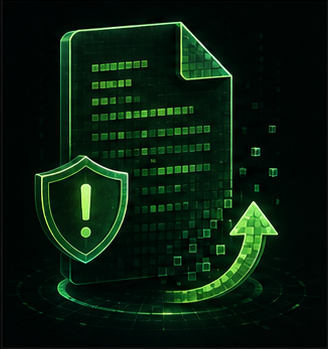

## 🎯 Aim

<div class="alert alert-block alert-info">
<b>Aim:</b> To perform file I/O operations (reading and writing text files) and to implement robust programs using built-in and custom exception handling.
</div>

## 🧩 Python Concepts Used

- File I/O: `open()`, the `with` statement, read/write modes
- `try` / `except` / custom exception classes
- Exception chaining (`raise ... from`)

## Question 1: The Permanent Record

### 📋 Problem Statement
> Add a few names (one per row) to `name.txt`, then count total names, count names starting with a vowel, and find the longest name.

<div class="alert alert-block alert-info">
<b>🧠 The Matrix Angle:</b> Every name that's ever jacked into the Matrix gets logged somewhere. Names are written to `name.txt`, read straight back, then analyzed.
</div>

### 🔄 Workflow
```mermaid
flowchart LR
    A["names list"] --> B["write to name.txt"]
    B --> C["read name.txt back"]
    C --> D["count total"]
    C --> E["count starting with vowel"]
    C --> F["find longest via max(key=len)"]
```

### ✅ Key Takeaway
<div class="alert alert-block alert-success">
<b>Key Takeaway:</b> Using `with open(...) as file:` guarantees the file is properly closed even if an error occurs partway through.
</div>

*Sample input/output for this problem is shown directly below, in the executed code cell's output — this notebook has already been run once end-to-end.*

In [1]:
names = ["Aarav", "Ishita", "Rahul", "Omkar", "Esha", "Vivek"]

with open("name.txt", "w", encoding="utf-8") as file:
    for name in names:
        file.write(name + "\n")

with open("name.txt", "r", encoding="utf-8") as file:
    stored_names = [line.strip() for line in file if line.strip()]

vowels = tuple("AEIOUaeiou")
count_names = len(stored_names)
count_vowel_start = sum(1 for name in stored_names if name.startswith(vowels))
longest_name = max(stored_names, key=len) if stored_names else None

print("Names in file:", stored_names)
print("Count of names:", count_names)
print("Names starting with vowel:", count_vowel_start)
print("Longest name:", longest_name)

Names in file: ['Aarav', 'Ishita', 'Rahul', 'Omkar', 'Esha', 'Vivek']
Count of names: 6
Names starting with vowel: 4
Longest name: Ishita


## Question 2: Parsing Sensor Logs

### 📋 Problem Statement
> Store integers in a file, then find the maximum number, the average of all numbers, and the count of numbers greater than 100.

<div class="alert alert-block alert-info">
<b>🧠 The Matrix Angle:</b> The same write-then-read pattern, numeric this time — readings written to `numbers.txt`, reloaded, and analyzed for maximum, average, and a threshold count.
</div>

### ✅ Key Takeaway
<div class="alert alert-block alert-success">
<b>Key Takeaway:</b> Every line read from a text file is a `str` by default — `int(line.strip())` is required before any arithmetic will work.
</div>

*Sample input/output for this problem is shown directly below, in the executed code cell's output — this notebook has already been run once end-to-end.*

In [2]:
numbers = [45, 120, 5, 300, 88, 150, 99]

with open("numbers.txt", "w", encoding="utf-8") as file:
    for number in numbers:
        file.write(f"{number}\n")

with open("numbers.txt", "r", encoding="utf-8") as file:
    values = [int(line.strip()) for line in file if line.strip()]

maximum_number = max(values)
average_number = sum(values) / len(values)
greater_than_100 = sum(1 for number in values if number > 100)

print("Numbers:", values)
print("Maximum number:", maximum_number)
print("Average of numbers:", round(average_number, 2))
print("Count > 100:", greater_than_100)

Numbers: [45, 120, 5, 300, 88, 150, 99]
Maximum number: 300
Average of numbers: 115.29
Count > 100: 3


## Question 3: The World's Background Data

### 📋 Problem Statement
> Given `city.txt` storing `city_name population_in_lakhs area_in_sq_km`, display all city details, cities with population > 10 lakhs, and the total area.

<div class="alert alert-block alert-info">
<b>🧠 The Matrix Angle:</b> City records are written as plain space-separated lines and parsed back into structured data — the Matrix's background 'world data' that most agents never think about.
</div>

### 🔄 Workflow
```mermaid
flowchart TD
    A["city.txt line"] --> B["line.split()"]
    B --> C["city, population, area"]
    C --> D["float(population), float(area)"]
    D --> E["parsed_cities list"]
```

### ✅ Key Takeaway
<div class="alert alert-block alert-success">
<b>Key Takeaway:</b> Checking `len(parts) == 3` before unpacking guards against a malformed line silently crashing the whole read.
</div>

*Sample input/output for this problem is shown directly below, in the executed code cell's output — this notebook has already been run once end-to-end.*

In [3]:
city_records = [
    ("Dehradun", 5.78, 308.20),
    ("Delhi", 190.00, 1484.00),
    ("Mumbai", 124.00, 603.40),
    ("Pune", 74.00, 331.26),
    ("Jaipur", 41.00, 484.60),
]

with open("city.txt", "w", encoding="utf-8") as file:
    for city, population, area in city_records:
        file.write(f"{city} {population} {area}\n")

parsed_cities = []
with open("city.txt", "r", encoding="utf-8") as file:
    for line in file:
        parts = line.split()
        if len(parts) == 3:
            city = parts[0]
            population = float(parts[1])
            area = float(parts[2])
            parsed_cities.append((city, population, area))

print("All city details:")
for city, population, area in parsed_cities:
    print(f"{city}: population={population} lakh, area={area} sq km")

high_population_cities = [city for city, population, _ in parsed_cities if population > 10]
total_area = sum(area for _, _, area in parsed_cities)

print("\nCities with population > 10 lakhs:", high_population_cities)
print("Sum of all city areas:", round(total_area, 2), "sq km")

All city details:
Dehradun: population=5.78 lakh, area=308.2 sq km
Delhi: population=190.0 lakh, area=1484.0 sq km
Mumbai: population=124.0 lakh, area=603.4 sq km
Pune: population=74.0 lakh, area=331.26 sq km
Jaipur: population=41.0 lakh, area=484.6 sq km

Cities with population > 10 lakhs: ['Delhi', 'Mumbai', 'Pune', 'Jaipur']
Sum of all city areas: 3211.46 sq km


## Question 4: Absorbing a Corrupted Value

### 📋 Problem Statement
> Input `N` test cases of `a b`, perform integer division `a // b`, and handle `ZeroDivisionError` and `ValueError`.

<div class="alert alert-block alert-info">
<b>🧠 The Matrix Angle:</b> Not every jack-in goes cleanly. This block processes test cases inside a `try/except`, catching bad input instead of crashing the whole simulation over it.
</div>

### 🔄 Workflow
```mermaid
flowchart TD
    A["a, b from input line"] --> B["try: int(a)//int(b)"]
    B --> C{"Exception?"}
    C -->|ZeroDivisionError| D["print Error Code"]
    C -->|ValueError| D
    C -->|None| E["print result"]
```

### ✅ Key Takeaway
<div class="alert alert-block alert-success">
<b>Key Takeaway:</b> Catching `(ZeroDivisionError, ValueError)` together in one `except` clause handles both failure modes with a single code path.
</div>

*Sample input/output for this problem is shown directly below, in the executed code cell's output — this notebook has already been run once end-to-end.*

In [4]:
raw_input_data = "3\n1 0\n2 $\n3 1"

lines = raw_input_data.strip().splitlines()
n = int(lines[0])

for line in lines[1:n + 1]:
    a_text, b_text = line.split()
    try:
        result = int(a_text) // int(b_text)
        print(result)
    except (ZeroDivisionError, ValueError) as error:
        print("Error Code:", error)

Error Code: integer division or modulo by zero
Error Code: invalid literal for int() with base 10: '$'
3


## Question 5: Naming the Glitch Precisely

### 📋 Problem Statement
> Create multiple suitable custom exceptions for a file-handling program that reads student marks.

<div class="alert alert-block alert-info">
<b>🧠 The Matrix Angle:</b> "A déjà vu is usually a glitch in the Matrix." Custom exceptions — `EmptyFileError` and `InvalidRecordError` — catch specific kinds of corruption rather than letting a bad file crash everything silently.
</div>

### 🔄 Workflow
```mermaid
flowchart TD
    A["read_student_marks(file)"] --> B{"file exists?"}
    B -->|No| C["raise FileNotFoundError"]
    B -->|Yes| D{"file empty?"}
    D -->|Yes| E["raise EmptyFileError"]
    D -->|No| F["for each line"]
    F --> G{"exactly 2 comma parts?"}
    G -->|No| H["raise InvalidRecordError"]
    G -->|Yes| I{"marks is numeric?"}
    I -->|No| H
    I -->|Yes| J["store in marks_data"]
```

### ✅ Key Takeaway
<div class="alert alert-block alert-success">
<b>Key Takeaway:</b> Custom exception classes that inherit from `Exception` let calling code catch *specific* failure types instead of a vague catch-all.
</div>

### ⚠️ Watch Out
<div class="alert alert-block alert-warning">
<b>Watch Out:</b> `raise ... from error` (exception chaining) preserves the original traceback, which is invaluable for debugging exactly *why* a file failed to parse.
</div>

*Sample input/output for this problem is shown directly below, in the executed code cell's output — this notebook has already been run once end-to-end.*

In [5]:
class EmptyFileError(Exception):
    pass


class InvalidRecordError(Exception):
    pass


def read_student_marks(file_name):
    try:
        with open(file_name, "r", encoding="utf-8") as file:
            lines = [line.strip() for line in file if line.strip()]
    except FileNotFoundError as error:
        raise FileNotFoundError(f"{file_name} not found.") from error

    if not lines:
        raise EmptyFileError(f"{file_name} is empty.")

    marks_data = {}
    for line in lines:
        parts = line.split(",")
        if len(parts) != 2:
            raise InvalidRecordError(f"Invalid line format: '{line}'")

        name = parts[0].strip()
        try:
            marks = float(parts[1].strip())
        except ValueError as error:
            raise InvalidRecordError(f"Marks must be numeric in line: '{line}'") from error

        marks_data[name] = marks

    return marks_data


with open("students_valid.txt", "w", encoding="utf-8") as file:
    file.write("Aditi,88\nRohan,76\n")

with open("students_invalid.txt", "w", encoding="utf-8") as file:
    file.write("Aditi-88\nRohan,abc\n")

for candidate in ["missing.txt", "students_invalid.txt", "students_valid.txt"]:
    try:
        data = read_student_marks(candidate)
        print(f"{candidate} -> {data}")
    except (FileNotFoundError, EmptyFileError, InvalidRecordError) as error:
        print(f"{candidate} -> {error}")

missing.txt -> missing.txt not found.
students_invalid.txt -> Invalid line format: 'Aditi-88'
students_valid.txt -> {'Aditi': 88.0, 'Rohan': 76.0}


## 🌟 Original Extension: Class-Average Calculator From File

<div class="alert alert-block alert-info">
<b>💡 Why this extension:</b> Q5 safely reads a student-marks file but stops at parsing it. This extension adds one more function that reuses that safe reader and reduces the result straight to a class average.
</div>

### 🔧 What It Adds

<div class="alert alert-block alert-success">
<b>New capability:</b> Chains file I/O, exception-safe parsing, and aggregation into a single reusable pipeline function.
</div>

In [6]:
class EmptyFileError(Exception):
    pass


class InvalidRecordError(Exception):
    pass


def read_student_marks(file_name):
    with open(file_name, "r", encoding="utf-8") as file:
        lines = [line.strip() for line in file if line.strip()]
    if not lines:
        raise EmptyFileError(f"{file_name} is empty.")
    marks_data = {}
    for line in lines:
        parts = line.split(",")
        if len(parts) != 2:
            raise InvalidRecordError(f"Invalid line: '{line}'")
        marks_data[parts[0].strip()] = float(parts[1].strip())
    return marks_data


def class_average_from_file(file_name):
    data = read_student_marks(file_name)
    return sum(data.values()) / len(data)


with open("students_valid.txt", "w", encoding="utf-8") as file:
    file.write("Aditi,88\nRohan,76\nMeera,91\n")

average = class_average_from_file("students_valid.txt")
print(f"Class average computed directly from file: {average:.2f}")

Class average computed directly from file: 85.00


## 📝 Conclusion

<div class="alert alert-block alert-success">
<b>📝 Conclusion:</b> This experiment combined file I/O with exception handling to build programs that read and write data robustly, even with missing files or malformed records. Custom exception classes made error handling both safer and more readable.
</div>

### 🗺️ Where You Are in the Arc

```mermaid
flowchart LR
    E1["1. Basics"]
    E2["2. Operators"]
    E3["3. Conditionals"]
    E4["4. Loops"]
    E5["5. Strings/Sets"]
    E6["6. Lists/Dict"]
    E7["7. Functions"]
    E8["8. Files/Errors"]
    E9["9. Classes"]
    E10["10. Data Viz"]
    E1 --> E2
    E2 --> E3
    E3 --> E4
    E4 --> E5
    E5 --> E6
    E6 --> E7
    E7 --> E8
    E8 --> E9
    E9 --> E10
    class E8 current;
    classDef current fill:#00ff41,stroke:#003b00,stroke-width:3px,color:#000,font-weight:bold;
```